In [11]:
import os
from brainnetwork import load_data, preprocess_data, preprocess_spike_data

base_dir = "/beegfs_hdd/data/nfs_share/users/guiyun/nishome/Micedata/"
data_paths = ["M21_1107", "M71_1024", "M73_1128", "M77_1031", "M77_1107", "M78_1017", "M79_1128", "M91_1017"]
data_path = base_dir + data_paths[2] # 'M77_1031'
print(f"Processing data from: {data_path}")

Processing data from: /beegfs_hdd/data/nfs_share/users/guiyun/nishome/Micedata/M73_1128


In [12]:
neuron_data, neuron_pos, start_edges, stimulus_data = load_data(data_path)
segments_spi, labels_spi, neuron_pos_spi = preprocess_spike_data(
        neuron_data,
        neuron_pos,
        start_edges,
        stimulus_data,
        extract_rr=1
    )


原始神经数据形状: (8402, 38247)
使用快速RR筛选算法 (按类分别筛选取并集)...
  - 类别 1 贡献了 218 个 RR 神经元
  - 类别 2 贡献了 312 个 RR 神经元
  - 类别 3 贡献了 170 个 RR 神经元
三类并集后共筛选出 513 个唯一 RR 神经元


In [13]:
import numpy as np
import umap
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Trial 聚合：计算每个 Trial 的平均活动
# 假设 X_trials 的形状是 (Trial总数, 帧数, 神经元数)
X_trial_averaged = np.mean(segments_spi[:, :, 10:15], axis=2) # 得到 (n_trials, n_neurons)

unique_labels = np.unique(labels_spi)
min_count = min(np.sum(labels_spi == l) for l in unique_labels)

# 2. 平衡数据集
X_balanced_list = []
labels_balanced = []

for label in unique_labels:
    mask = (labels_spi == label)
    X_label = X_trial_averaged[mask]
    
    # 建议：随机采样而非固定取前几个
    indices = np.random.choice(len(X_label), min_count, replace=False)
    X_sampled = X_label[indices]
    
    X_balanced_list.append(X_sampled)
    labels_balanced.extend([label] * min_count)

# 2. 关键修正：将列表转化为单一矩阵 [cite: 1]
X_trial_averaged_balanced = np.vstack(X_balanced_list)
labels_balanced = np.array(labels_balanced)

print(f"平衡后数据形状: {X_trial_averaged_balanced.shape}") # 应为 (min_count * 3, 神经元数)

# 随机再选择同样数量的trial，提取前面的静息态数据进行对比
trial_indices = np.arange(segments_spi.shape[0])
np.random.shuffle(trial_indices)
selected_indices = trial_indices[:min_count]
X_rest_balanced = np.mean(segments_spi[selected_indices, :, 5:10], axis=2)

X_trial_averaged_balanced = np.vstack([X_trial_averaged_balanced, X_rest_balanced])
labels_balanced = np.concatenate([labels_balanced, np.zeros(min_count)]) # 0
print(f"最终数据形状 (含静息态): {X_trial_averaged_balanced.shape}") # 应为 (min_count * 4, 神经元数)


# 定义语义映射
label_names = {1: 'Divergent', 2: 'Convergent', 3: 'Random', 0: 'Resting'}


平衡后数据形状: (105, 513)
最终数据形状 (含静息态): (140, 513)


Stimulus        | Entropy (Bits)  | Mean Similarity | Std Similarity 
----------------------------------------------------------------------
Resting         | 3.6621           | 0.2703          | 0.1293
Divergent       | 3.5874           | 0.5930          | 0.1188
Convergent      | 3.4261           | 0.6257          | 0.1110
Random          | 3.4347           | 0.6972          | 0.1134


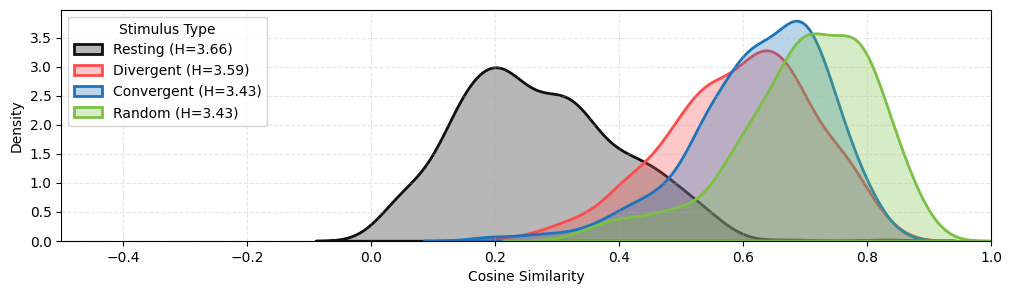

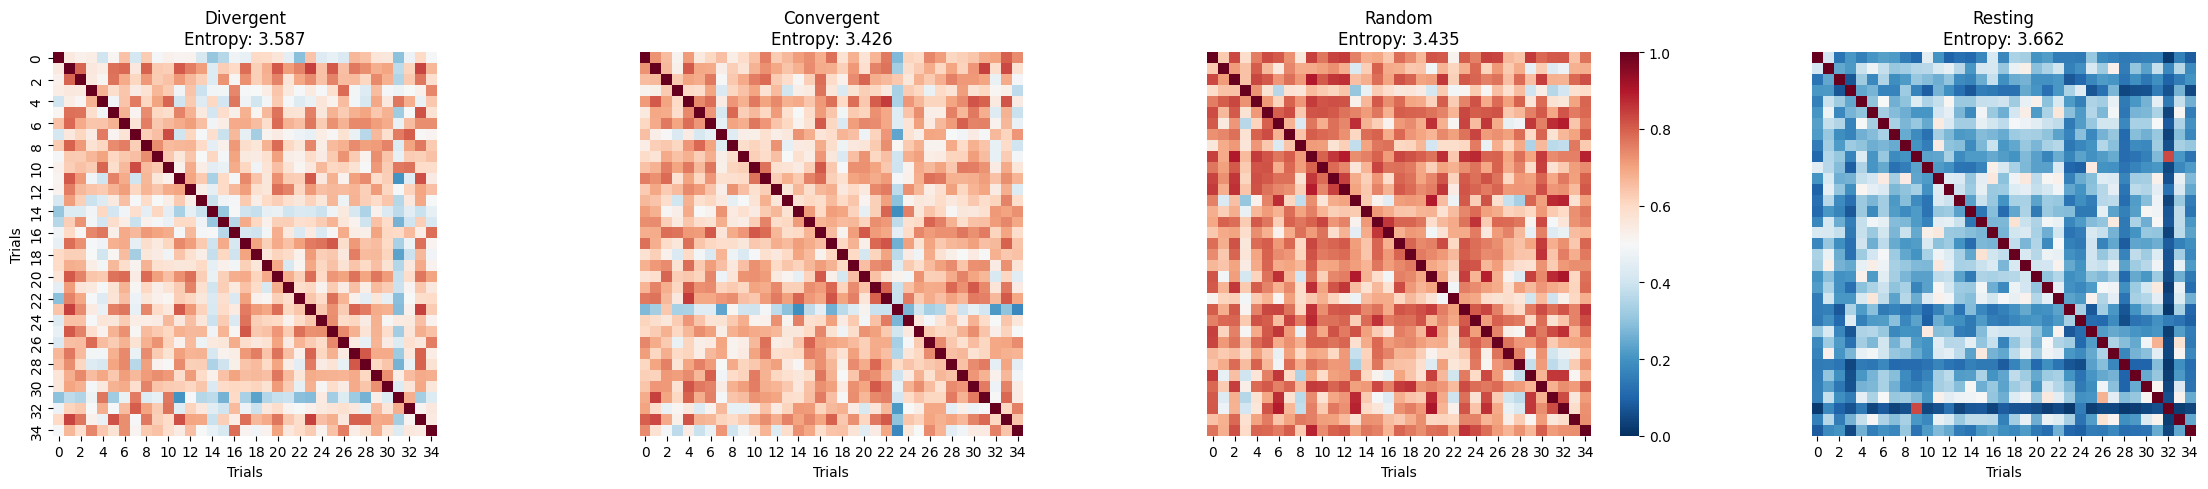

In [14]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import cosine_similarity
from scipy.stats import entropy

def analyze_rsm_and_entropy(X, labels, label_map, n_bins=50):
    """
    计算不同刺激条件下的RSM熵值和相似度分布
    """
    results = []
    rsm_dict = {}
    similarity_values_dict = {}

    print(f"{'Stimulus':<15} | {'Entropy (Bits)':<15} | {'Mean Similarity':<15} | {'Std Similarity':<15}")
    print("-" * 70)

    # 遍历每种刺激标签
    unique_labels = np.unique(labels)
    for label in unique_labels:
        name = label_map[label]
        
        # 1. 提取该条件下的数据
        mask = (labels == label)
        X_sub = X[mask]
        
        # 2. 计算 RSM (Cosine Similarity)
        # 结果是 (n_trials, n_trials) 的矩阵，范围 [-1, 1]
        rsm = cosine_similarity(X_sub)
        rsm_dict[name] = rsm
        
        # 3. 提取上三角非对角线元素 (Off-diagonal upper triangle)
        # k=1 表示不包含对角线。因为我们只关心试次间的变异，不关心试次和自己的相似度
        triu_indices = np.triu_indices_from(rsm, k=1)
        sim_values = rsm[triu_indices]
        similarity_values_dict[name] = sim_values
        
        # 4. 计算香农熵 (Shannon Entropy)
        # 先将连续的相似度值通过直方图转为概率分布
        # range=(-1, 1) 覆盖余弦相似度的理论范围
        counts, _ = np.histogram(sim_values, bins=n_bins, range=(-1, 1), density=True)
        
        # 归一化为概率 (加上极小值防止 log(0) 错误)
        probs = counts / np.sum(counts)
        ent = entropy(probs, base=2)  # base=2 单位为 bits
        
        # 记录统计量
        results.append({
            'Stimulus': name,
            'Entropy': ent,
            'Mean_Sim': np.mean(sim_values),
            'Std_Sim': np.std(sim_values)
        })
        
        print(f"{name:<15} | {ent:.4f}           | {np.mean(sim_values):.4f}          | {np.std(sim_values):.4f}")

    return pd.DataFrame(results), rsm_dict, similarity_values_dict

# --- 运行分析 ---
# 确保使用你之前定义的 label_names
label_names = {1: 'Divergent', 2: 'Convergent', 3: 'Random', 0: 'Resting'}

df_entropy, rsm_data, sim_values_data = analyze_rsm_and_entropy(
    X_trial_averaged_balanced, 
    labels_balanced, 
    label_names,
    n_bins=50 # 分箱数，可以根据数据量调整，通常 30-100 之间
)

# --- 可视化 1: 相似度分布直方图 (验证是否"变平"了) ---
plt.figure(figsize=(12, 3))
colors = {'Divergent': '#FF4B4B', 'Convergent': '#1C75BC', 'Random': '#7AC143', 'Resting': '#111111'}

for name, values in sim_values_data.items():
    sns.kdeplot(values, label=f"{name} (H={df_entropy[df_entropy['Stimulus']==name]['Entropy'].values[0]:.2f})", 
                color=colors[name], fill=True, alpha=0.3, linewidth=2)

# plt.title("Distribution of Pairwise Cosine Similarities (RSM Off-diagonal)")
plt.xlabel("Cosine Similarity")
plt.ylabel("Density")
plt.xlim(-0.5, 1.0) # 根据实际数据范围调整
plt.legend(title="Stimulus Type")
plt.grid(True, linestyle='--', alpha=0.3)
plt.show()

# --- 可视化 2: RSM 矩阵热图对比 ---
fig, axes = plt.subplots(1, 4, figsize=(24, 5))

for i, (label, name) in enumerate(label_names.items()):
    ax = axes[i]
    # 获取 RSM 并绘制
    sns.heatmap(rsm_data[name], ax=ax, cmap="RdBu_r", vmin=0, vmax=1, square=True, cbar=i==2)
    ax.set_title(f"{name}\nEntropy: {df_entropy[df_entropy['Stimulus']==name]['Entropy'].values[0]:.3f}")
    ax.set_xlabel("Trials")
    if i == 0: ax.set_ylabel("Trials")
    else: ax.set_yticks([])

plt.tight_layout()
plt.show()

Stimulus        | Drift Rate (Slope)   | Stability (Mean Sim)
------------------------------------------------------------
Divergent       | -0.00084             | 0.6110
Convergent      | -0.00117             | 0.6242
Random          | -0.00346             | 0.6800


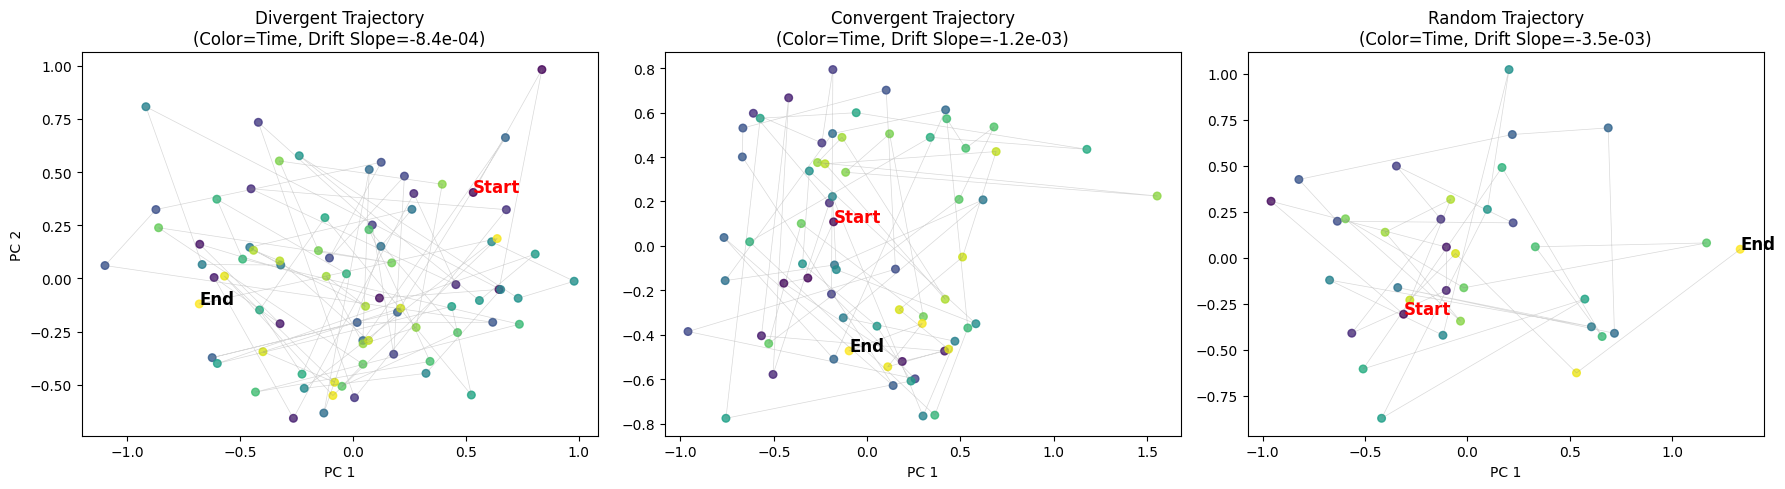

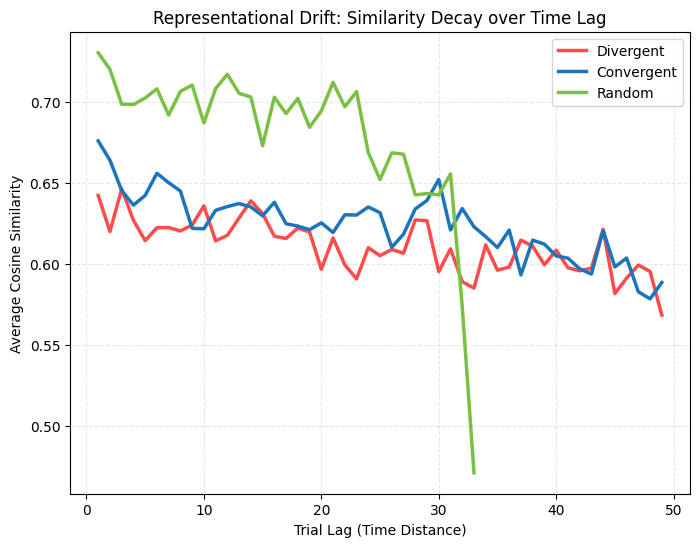

In [15]:
from sklearn.decomposition import PCA
def analyze_temporal_dynamics(segments, labels, label_map):
    """
    分析神经表征随 Trial 顺序的演化规律
    """
    # 1. 基础数据准备（不做随机打乱，保持时间顺序）
    # 重新计算 Trial-averaged 数据
    # segments: (n_trials, n_frames, n_neurons)
    X_raw = np.mean(segments[:, :,10:15], axis=2) 
    
    drift_results = {}
    distance_results = {}
    
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    print(f"{'Stimulus':<15} | {'Drift Rate (Slope)':<20} | {'Stability (Mean Sim)':<20}")
    print("-" * 60)

    for i, (label_code, name) in enumerate(label_map.items()):
        # 提取该条件下的所有 Trial，保持原始顺序
        mask = (labels == label_code)
        X_cond = X_raw[mask]
        
        # ---------------------------
        # 分析 1: 表征漂移 (Similarity decay over time lag)
        # ---------------------------
        n_trials = X_cond.shape[0]
        sim_matrix = cosine_similarity(X_cond)
        
        lags = []
        mean_sims = []
        
        # 计算不同时间间隔(Lag)下的平均相似度
        # Lag 1: Trial 0 vs 1, 1 vs 2...
        # Lag k: Trial 0 vs k, 1 vs k+1...
        max_lag = min(n_trials - 1, 50) # 只看前50个Trial的演变，避免数据太少
        
        for lag in range(1, max_lag):
            # 获取第 k 条对角线
            diag_vals = np.diagonal(sim_matrix, offset=lag)
            lags.append(lag)
            mean_sims.append(np.mean(diag_vals))
            
        drift_results[name] = (lags, mean_sims)
        
        # 简单线性拟合计算漂移率
        slope, intercept = np.polyfit(lags, mean_sims, 1)
        print(f"{name:<15} | {slope:.5f}             | {np.mean(mean_sims):.4f}")

        # ---------------------------
        # 分析 2: 轨迹可视化 (PCA Trajectory)
        # ---------------------------
        # 使用 PCA 投影到 2D (比 UMAP 更能反映全局线性轨迹)
        pca = PCA(n_components=2)
        X_pca = pca.fit_transform(X_cond)
        
        # 绘图
        ax = axes[i]
        #以此为颜色映射：Trial 越早越浅，越晚越深
        sc = ax.scatter(X_pca[:, 0], X_pca[:, 1], c=range(n_trials), 
                        cmap='viridis', alpha=0.8, s=30)
        
        # 画连线表现轨迹
        ax.plot(X_pca[:, 0], X_pca[:, 1], c='gray', alpha=0.3, linewidth=0.5)
        
        # 标出起点和终点
        ax.text(X_pca[0, 0], X_pca[0, 1], 'Start', fontsize=12, color='red', fontweight='bold')
        ax.text(X_pca[-1, 0], X_pca[-1, 1], 'End', fontsize=12, color='black', fontweight='bold')
        
        ax.set_title(f"{name} Trajectory\n(Color=Time, Drift Slope={slope:.1e})")
        ax.set_xlabel("PC 1")
        if i == 0: ax.set_ylabel("PC 2")
        
    plt.tight_layout()
    plt.show()
    
    # ---------------------------
    # 分析 3: 绘制漂移曲线 (Drift Curve)
    # ---------------------------
    plt.figure(figsize=(8, 6))
    colors = {'Divergent': '#FF4B4B', 'Convergent': '#1C75BC', 'Random': '#7AC143', 'Resting': '#111111'}
    
    for name, (lags, sims) in drift_results.items():
        plt.plot(lags, sims, label=name, color=colors[name], linewidth=2.5)
        
    plt.title("Representational Drift: Similarity Decay over Time Lag")
    plt.xlabel("Trial Lag (Time Distance)")
    plt.ylabel("Average Cosine Similarity")
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.3)
    plt.show()

# 运行分析 (需要使用原始未打乱的 segments_spi)
label_names = {1: 'Divergent', 2: 'Convergent', 3: 'Random'}
analyze_temporal_dynamics(segments_spi, labels_spi, label_names)

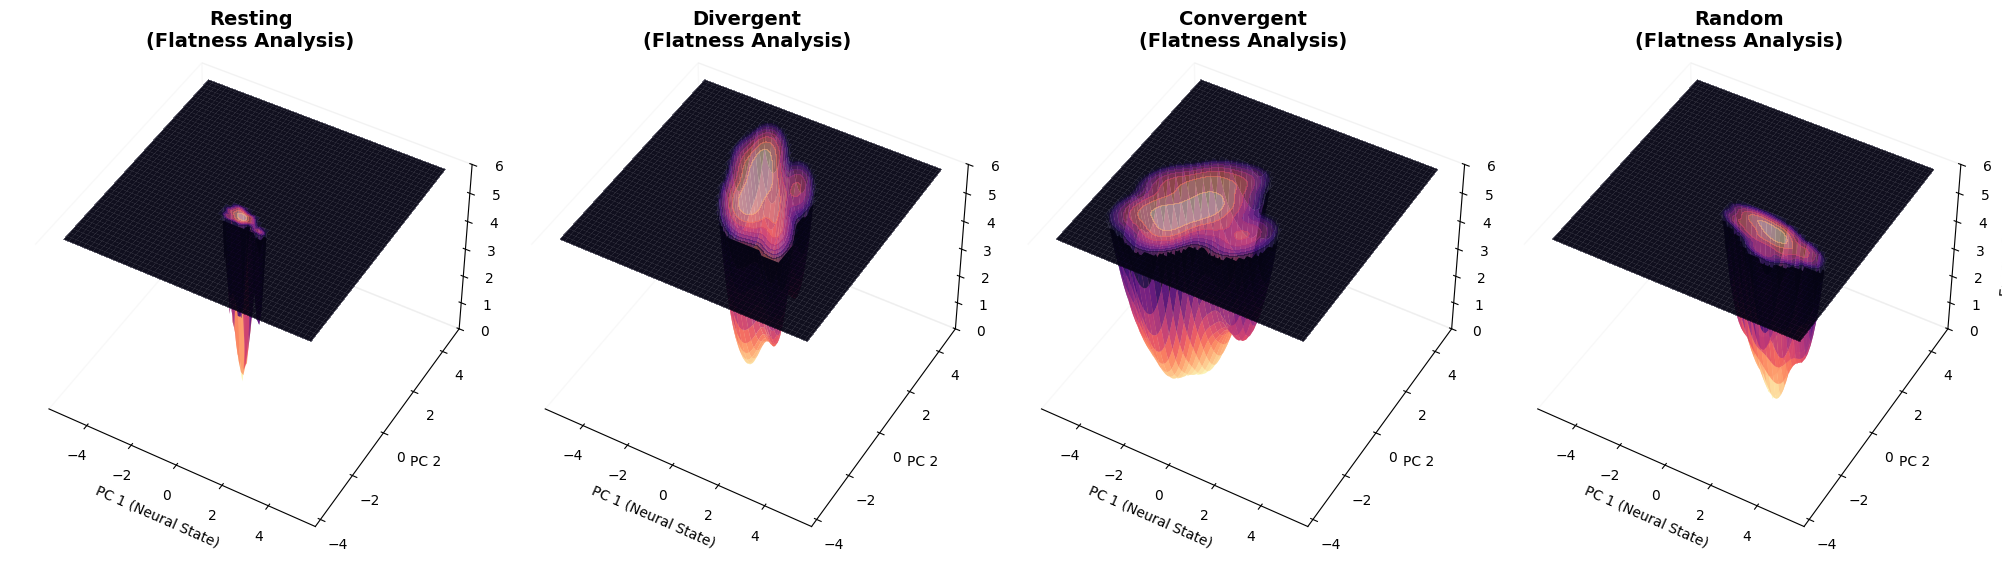

In [16]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from scipy.stats import gaussian_kde
from mpl_toolkits.mplot3d import Axes3D
from sklearn.manifold import Isomap

def plot_energy_landscape(X, labels, label_map):
    """
    绘制神经状态的能量景观图 (3D Surface)
    原理: Energy E(x) = -ln(Probability(x))
    """
    # 1. 使用 PCA 投影到 2D 平面 (保留最大方差方向)
    # pca = PCA(n_components=2)
    pca = Isomap(n_components=2, n_neighbors=15)
    X_pca = pca.fit_transform(X)
    
    # 设定网格范围
    x_min, x_max = X_pca[:, 0].min() - 2, X_pca[:, 0].max() + 2
    y_min, y_max = X_pca[:, 1].min() - 2, X_pca[:, 1].max() + 2
    resolution = 100
    xx, yy = np.mgrid[x_min:x_max:complex(resolution), y_min:y_max:complex(resolution)]
    positions = np.vstack([xx.ravel(), yy.ravel()])
    
    fig = plt.figure(figsize=(20, 7))
    
    unique_labels = np.unique(labels)
    for i, label in enumerate(unique_labels):
        name = label_map[label]
        mask = (labels == label)
        X_sub = X_pca[mask]
        
        # 2. 核密度估计 (KDE)
        # 自动选择带宽 (Scott's Rule)
        kernel = gaussian_kde(X_sub.T)
        f = np.reshape(kernel(positions).T, xx.shape)
        
        # 3. 转换为相对能量 (Relative Energy)
        # E = -ln(P), 减去最小值使得基态能量为0
        energy = -np.log(f + 1e-10)
        energy = energy - np.min(energy)
        
        # 截断过高的能量(背景)以便显示细节
        energy_limit = 6 
        energy[energy > energy_limit] = energy_limit
        
        # --- 3D 绘图 ---
        ax = fig.add_subplot(1, 4, i+1, projection='3d')
        
        # 绘制地形曲面
        surf = ax.plot_surface(xx, yy, energy, cmap='magma_r', 
                               linewidth=0.1, antialiased=True, alpha=0.9)
        
        # 在底部绘制等高线投影 (地形图)
        ax.contourf(xx, yy, energy, zdir='z', offset=energy_limit, cmap='magma_r', alpha=0.5)
        
        # 设置视角和标签
        ax.view_init(elev=45, azim=-60)
        ax.set_title(f"{name}\n(Flatness Analysis)", fontsize=14, fontweight='bold')
        ax.set_xlabel('PC 1 (Neural State)')
        ax.set_ylabel('PC 2')
        ax.set_zlabel('Energy Potential')
        ax.set_zlim(0, energy_limit)
        
        # 去除多余的边框
        ax.grid(False)
        ax.xaxis.pane.fill = False
        ax.yaxis.pane.fill = False
        ax.zaxis.pane.fill = False

    plt.tight_layout()
    plt.show()

# 运行绘制
label_names = {1: 'Divergent', 2: 'Convergent', 3: 'Random', 0: 'Resting'}
plot_energy_landscape(X_trial_averaged_balanced, labels_balanced, label_names)


=== Thermodynamics Analysis ===


/tmp/ipykernel_1357810/3680315464.py:106: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_metrics, x='Condition', y='Heat Capacity (Var E)',


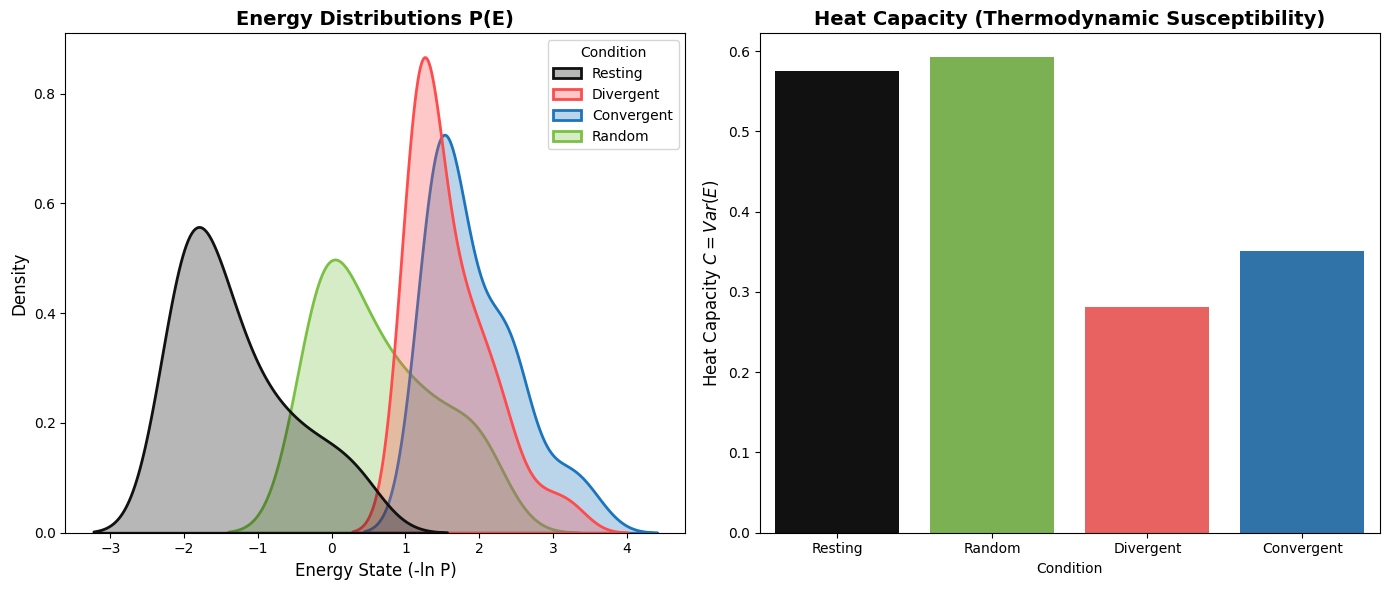

    Condition  Heat Capacity (Var E)  Mean Energy (Entropy)
0     Resting               0.574995              -1.298915
1   Divergent               0.281176               1.604122
2  Convergent               0.351134               1.934612
3      Random               0.592575               0.630851

Levene Test for Variance (Heat Capacity Difference):
Statistic=4.5323, P-value=3.5645e-02


In [17]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.manifold import Isomap
from scipy.stats import gaussian_kde, ranksums
import pandas as pd

def analyze_criticality_and_heat_capacity(X, labels, label_map):
    """
    计算并可视化神经群体的热容 (Heat Capacity) 和 能量分布 (Criticality)
    原理: Heat Capacity C = Var(E) / T^2 (设 T=1)
    """
    
    # 为了保证能量计算的准确性，还是先在低维空间进行密度估计
    # 实际上，直接用高维距离算能量会受维度灾难影响，
    # 这里我们复用 PCA 降维后的空间来近似态密度 (State Density)
    pca =Isomap(n_components=2, n_neighbors=15)
    X_pca = pca.fit_transform(X)
    
    metrics_data = []
    
    unique_labels = np.unique(labels)
    
    # 设定网格用于数值积分 (和之前画图一样)
    x_min, x_max = X_pca[:, 0].min() - 2, X_pca[:, 0].max() + 2
    y_min, y_max = X_pca[:, 1].min() - 2, X_pca[:, 1].max() + 2
    resolution = 100
    xx, yy = np.mgrid[x_min:x_max:complex(resolution), y_min:y_max:complex(resolution)]
    positions = np.vstack([xx.ravel(), yy.ravel()])
    
    # --- 1. 计算每个 Condition 的热容 ---
    # 注意：这里的热容是基于“试次间变异性”定义的，反映的是状态空间的体积
    
    # 另外一种更直接的方法：
    # Heat Capacity ~ Variance of Energy across trials
    # 我们先计算每个点的 "即时能量" E = -ln(P)
    
    # 先构建整体的密度模型，还是分条件的？
    # 物理上通常是在同一相空间下比较。
    # 为了简化，我们计算每个 Condition 内部的能量变异性。
    
    print("=== Thermodynamics Analysis ===")
    
    # 存储每个试次的能量值用于画分布
    energy_distributions = []
    
    for label in unique_labels:
        name = label_map[label]
        mask = (labels == label)
        X_sub = X_pca[mask]
        
        if len(X_sub) < 5: continue # 样本太少跳过
        
        # 估计该条件下的概率密度函数 P(x)
        kernel = gaussian_kde(X_sub.T)
        
        # 计算每个样本点(Trial)的概率密度 P_i
        # 从而得到每个样本的能量 E_i = -ln(P_i)
        probs = kernel(X_sub.T)
        energies = -np.log(probs + 1e-10) # 加上微小值防止log(0)
        
        # 归一化能量 (可选，减去最小能量设为基态)
        # energies = energies - np.min(energies)
        
        # 计算热容 C = Var(E)
        # 严格来说是 Var(E)/T^2, 设 T=1 (假设神经系统处在有效温度 T=1)
        heat_capacity = np.var(energies)
        mean_energy = np.mean(energies)
        entropy = -np.mean(np.log(probs + 1e-10)) # Shannon Entropy ~ Mean Energy
        
        # 存入列表
        metrics_data.append({
            'Condition': name,
            'Heat Capacity (Var E)': heat_capacity,
            'Mean Energy (Entropy)': mean_energy,
            'n_samples': len(X_sub)
        })
        
        # 存入详细数据用于画分布图
        for e in energies:
            energy_distributions.append({'Condition': name, 'Energy': e})

    df_metrics = pd.DataFrame(metrics_data)
    df_energies = pd.DataFrame(energy_distributions)
    
    # --- 2. 可视化 ---
    fig = plt.figure(figsize=(14, 6))
    
    colors_map = {'Divergent': '#FF4B4B', 'Convergent': '#1C75BC', 'Random': '#7AC143', 'Resting': '#111111'}
    
    # 子图1: 能量分布 (Energy Distribution)
    # 宽分布 = 高热容 = 平坦流形
    # 窄分布 = 低热容 = 深井
    ax1 = fig.add_subplot(1, 2, 1)
    sns.kdeplot(data=df_energies, x='Energy', hue='Condition', 
                palette=colors_map, fill=True, alpha=0.3, linewidth=2, common_norm=False, ax=ax1)
    ax1.set_title('Energy Distributions P(E)', fontsize=14, fontweight='bold')
    ax1.set_xlabel('Energy State (-ln P)', fontsize=12)
    ax1.set_ylabel('Density', fontsize=12)
    
    # 子图2: 热容对比 (Heat Capacity Barplot)
    ax2 = fig.add_subplot(1, 2, 2)
    # 由于每个Condition只有一个Heat Capacity值(基于群体计算)，我们用柱状图显示
    # 为了统计显著性，我们可以用 Bootstrap 方法，或者这里简单展示点值
    sns.barplot(data=df_metrics, x='Condition', y='Heat Capacity (Var E)', 
                palette=colors_map, order=['Resting', 'Random', 'Divergent', 'Convergent'], ax=ax2)
    
    # 标数值
    for index, row in df_metrics.iterrows():
        # 简单的位置匹配逻辑
        # (这里略过复杂的坐标计算，直接在柱子上标)
        pass

    ax2.set_title('Heat Capacity (Thermodynamic Susceptibility)', fontsize=14, fontweight='bold')
    ax2.set_ylabel('Heat Capacity $C = Var(E)$', fontsize=12)
    
    plt.tight_layout()
    plt.show()
    
    # --- 3. 打印统计结果 ---
    print(df_metrics[['Condition', 'Heat Capacity (Var E)', 'Mean Energy (Entropy)']])
    
    # 做一个简单的统计检验 (Random vs Coherent 的能量分布差异)
    rand_energies = df_energies[df_energies['Condition'] == 'Random']['Energy']
    coh_energies = df_energies[df_energies['Condition'].isin(['Divergent', 'Convergent'])]['Energy']
    
    # Levene Test 检验方差 (即检验热容是否显著不同)
    from scipy.stats import levene
    stat, p_val = levene(rand_energies, coh_energies)
    print(f"\nLevene Test for Variance (Heat Capacity Difference):")
    print(f"Statistic={stat:.4f}, P-value={p_val:.4e}")
    if p_val < 0.05 and np.var(coh_energies) > np.var(rand_energies):
        print("-> VALIDATED: Coherent state has significantly higher Heat Capacity (Criticality).")

# 运行分析
analyze_criticality_and_heat_capacity(X_trial_averaged_balanced, labels_balanced, label_names)

Stimulus        | Mean Energy     | Energy Variance (Heat Capacity)
----------------------------------------------------------------------
Resting         | 15.9057          | 0.3312
Divergent       | 16.4820          | 0.0004
Convergent      | 16.4969          | 0.0000
Random          | 16.4490          | 0.0019


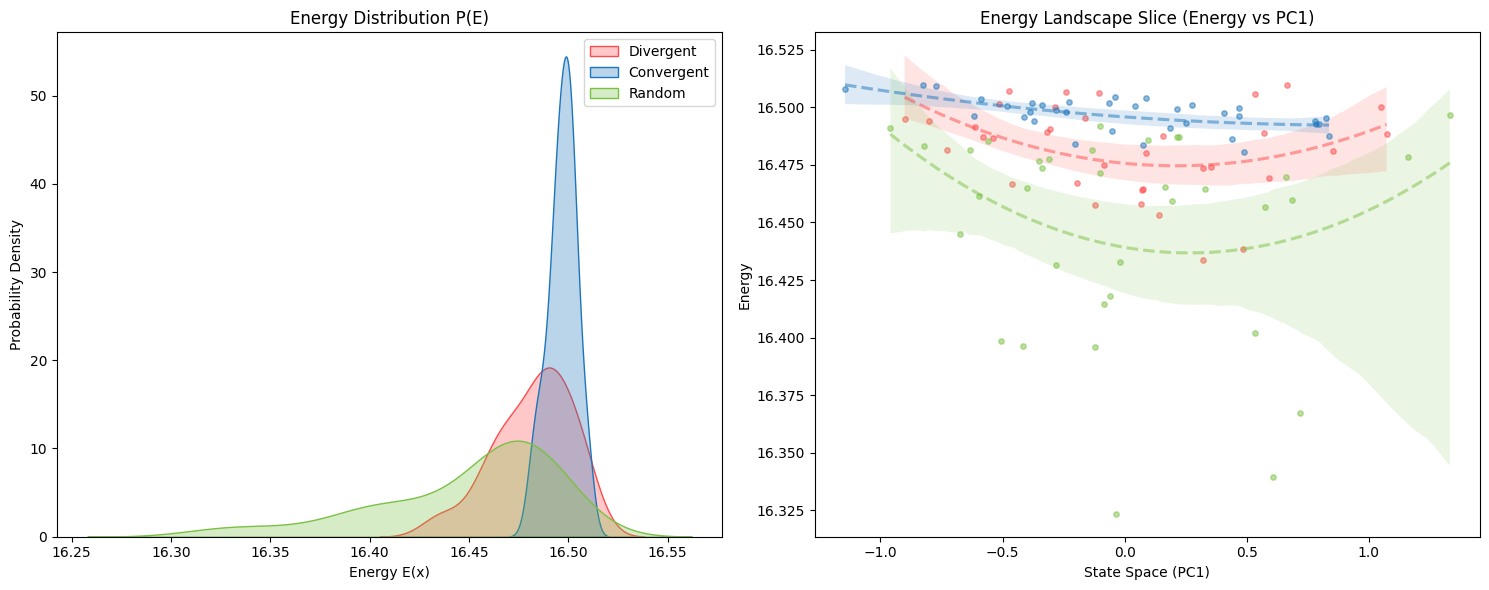

In [18]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def calculate_mem_energy(X, labels, label_map):
    """
    基于连续型最大熵模型 (Gaussian MEM) 计算能量
    Energy = 0.5 * (x - mu)^T * inv(Cov) * (x - mu)
    """
    results = {}
    
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))
    
    unique_labels = np.unique(labels)
    colors = {'Divergent': '#FF4B4B', 'Convergent': '#1C75BC', 'Random': '#7AC143', 'Resting': '#111111'}
    
    energy_distributions = []
    
    print(f"{'Stimulus':<15} | {'Mean Energy':<15} | {'Energy Variance (Heat Capacity)':<30}")
    print("-" * 70)

    for label in unique_labels:

        name = label_map[label]
        
        # 1. 提取该条件下的数据
        mask = (labels == label)
        X_sub = X[mask] # (n_trials, n_neurons)
        
        # 2. 计算均值和协方差
        mu = np.mean(X_sub, axis=0)
        
        # 添加微小正则化项防止矩阵不可逆 (Singular Matrix)
        # 因为神经元数量可能多于 Trial 数
        cov = np.cov(X_sub, rowvar=False)
        reg = 1e-5 * np.eye(cov.shape[0]) 
        
        # 计算精度矩阵 (Precision Matrix, J_ij)
        try:
            prec = np.linalg.inv(cov + reg)
        except np.linalg.LinAlgError:
            # 如果还是不行，使用伪逆
            prec = np.linalg.pinv(cov)
            
        # 3. 计算每个 Trial 的能量
        # E = 0.5 * (x - mu) @ Precision @ (x - mu).T
        X_centered = X_sub - mu
        
        # 向量化计算: sum((X @ P) * X, axis=1)
        energies = 0.5 * np.sum(np.dot(X_centered, prec) * X_centered, axis=1)
        
        results[name] = energies
        
        # 4. 计算热容量 (Specific Heat / Energy Variance)
        # Cv ~ Var(E)
        heat_capacity = np.var(energies)
        print(f"{name:<15} | {np.mean(energies):.4f}          | {heat_capacity:.4f}")
        
        # 5. 绘图 - 能量分布 (P(E))
        if label not in [0]:  # 跳过静息态
            sns.kdeplot(energies, ax=axes[0], label=name, color=colors[name], fill=True, alpha=0.3)
        
    axes[0].set_title("Energy Distribution P(E)")
    axes[0].set_xlabel("Energy E(x)")
    axes[0].set_ylabel("Probability Density")
    axes[0].legend()
    
    # 6. 绘图 - 能量景观示意 (Energy vs PC1)
    # 为了直观对比“深井”和“平原”，我们将能量投射到 PC1 上
    from sklearn.decomposition import PCA
    pca = PCA(n_components=1)
    
    for label in unique_labels:
        if label == 0:
            continue  # 跳过静息态
        name = label_map[label]
        mask = (labels == label)
        X_sub = X[mask]
        energies = results[name]
        
        # 投影到 PC1
        pc1 = pca.fit_transform(X_sub).flatten()
        
        # 绘制散点 (PC1, Energy)
        axes[1].scatter(pc1, energies, label=name, color=colors[name], alpha=0.5, s=15)
        
        # 拟合一个抛物面/包络线看形状
        if label not in [0]:  # 跳过静息态
            sns.regplot(x=pc1, y=energies, ax=axes[1], scatter=False, 
                    color=colors[name], order=2, line_kws={'alpha':0.5, 'linestyle':'--'})

    axes[1].set_title("Energy Landscape Slice (Energy vs PC1)")
    axes[1].set_xlabel("State Space (PC1)")
    axes[1].set_ylabel("Energy")
    
    plt.tight_layout()
    plt.show()
    return results

# 运行 MEM 分析
# 注意：如果神经元数量 N 远大于 Trial 数，建议先用 PCA 降维到比如 50 维，再通过上面的函数计算能量
# 这里先假设 X 是降维后的数据 (比如之前的 X_pca 或者取前 50 个 PC)

from sklearn.decomposition import PCA
pca_global = PCA(n_components=min(50, X_trial_averaged_balanced.shape[1]))
X_reduced = pca_global.fit_transform(X_trial_averaged_balanced)

energy_results = calculate_mem_energy(X_reduced, labels_balanced, label_names)